In [103]:
import sys
import os
from pathlib import Path

import numpy as np
import math
from functools import partial


In [104]:
path = "C:\josim_projects"
file_in = 'AQFP_TEST'  #input .cir file
file_out = file_in #output .dat and .csv files

os.chdir(path)
os.system(f"josim-cli ./{file_in}.cir -V 1")

<>:1: SyntaxWarning: "\j" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\j"? A raw string is also an option.
<>:1: SyntaxWarning: "\j" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\j"? A raw string is also an option.
C:\Users\Арина\AppData\Local\Temp\ipykernel_31820\463195032.py:1: SyntaxWarning: "\j" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\j"? A raw string is also an option.
  path = "C:\josim_projects"


0

In [105]:
data = np.genfromtxt(f"{file_out}.dat", delimiter=None, skip_header=1)
time = data[:, 0] * 10**12
p_x = data[:, 1]
p_out = data[:, 2]
p_B01 = data[:, 3]
p_B02 = data[:, 4]
print(data.shape) #узнать размер массива

(17999, 5)


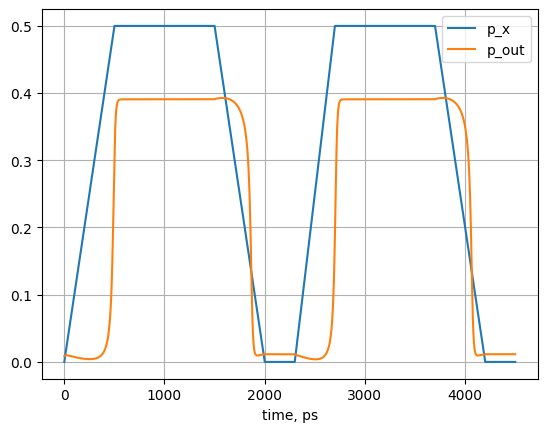

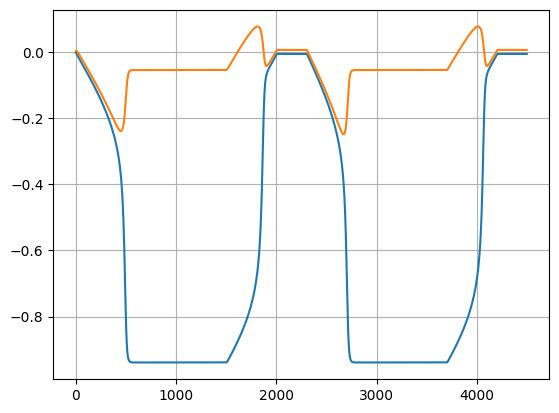

In [106]:
import matplotlib.pyplot as plt
plt.plot(time, p_x / (2*math.pi),label='p_x')
plt.xlabel('time, ps') 
plt.plot(time, p_out / (2*math.pi),label='p_out')
plt.legend()
plt.grid()
plt.xticks()
plt.yticks()
plt.show()
plt.plot(time, p_B01 / (2*math.pi))
plt.plot(time, p_B02 / (2*math.pi))
plt.grid()
plt.show()

In [107]:
p_minus = (p_B01-p_B02)/2
p_plus = (p_B01+p_B02)/2 
beta_L = 1 # L1
beta_q = 3 # Lq
p_in = 0.04 # Iin

idx_max = np.argmax(p_x)
idx_min = np.argmin(p_x)
print(idx_max)
print(idx_min)
idx1 = 0
idx2 = 500
idx3 = 999
p_plus_2d = np.linspace(-2*np.pi, 2*np.pi, 100)
p_minus_2d = np.linspace(-2*np.pi, 2*np.pi, 100)
P_plus, P_minus = np.meshgrid(p_plus_2d, p_minus_2d)
p_x_fixed_1 = p_x[idx1]
p_x_fixed_2 = p_x[idx2]
p_x_fixed_3 = p_x[idx3]

U_qfp_norm_1 = (p_x_fixed_1 - P_minus)**2/beta_L + (p_in - P_plus)**2/(beta_L+2*beta_q) - 2*np.cos(P_minus)*np.cos(P_plus)
U_qfp_norm_2 = (p_x_fixed_2 - P_minus)**2/beta_L + (p_in - P_plus)**2/(beta_L+2*beta_q) - 2*np.cos(P_minus)*np.cos(P_plus)
U_qfp_norm_3 = (p_x_fixed_3 - P_minus)**2/beta_L + (p_in - P_plus)**2/(beta_L+2*beta_q) - 2*np.cos(P_minus)*np.cos(P_plus)

1999
0


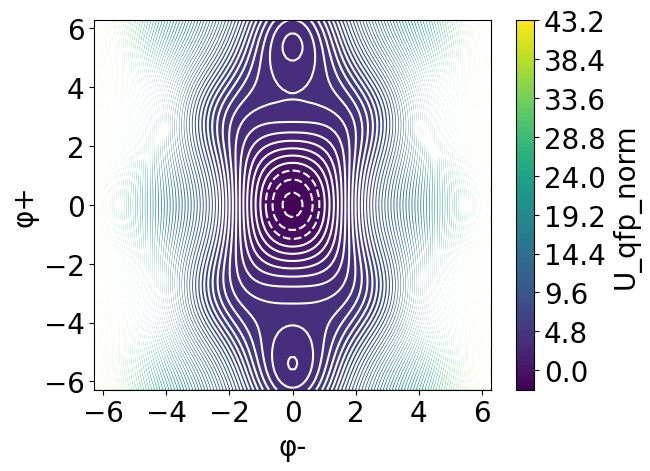

In [108]:

plt.figure()
contour_lines = plt.contour(P_minus,P_plus, U_qfp_norm_1, levels=80, colors='white', linewidths=1.5)
plt.contourf(P_minus, P_plus, U_qfp_norm_1, levels=80, cmap='viridis')
cbar = plt.colorbar(label='U_qfp_norm')
cbar.ax.set_ylabel('U_qfp_norm', fontsize=20)
plt.xlabel('φ-', fontsize=20)
plt.ylabel('φ+', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
cbar.ax.tick_params(labelsize=20)
#plt.title('Поверхность потенциальной энергии AQFP')


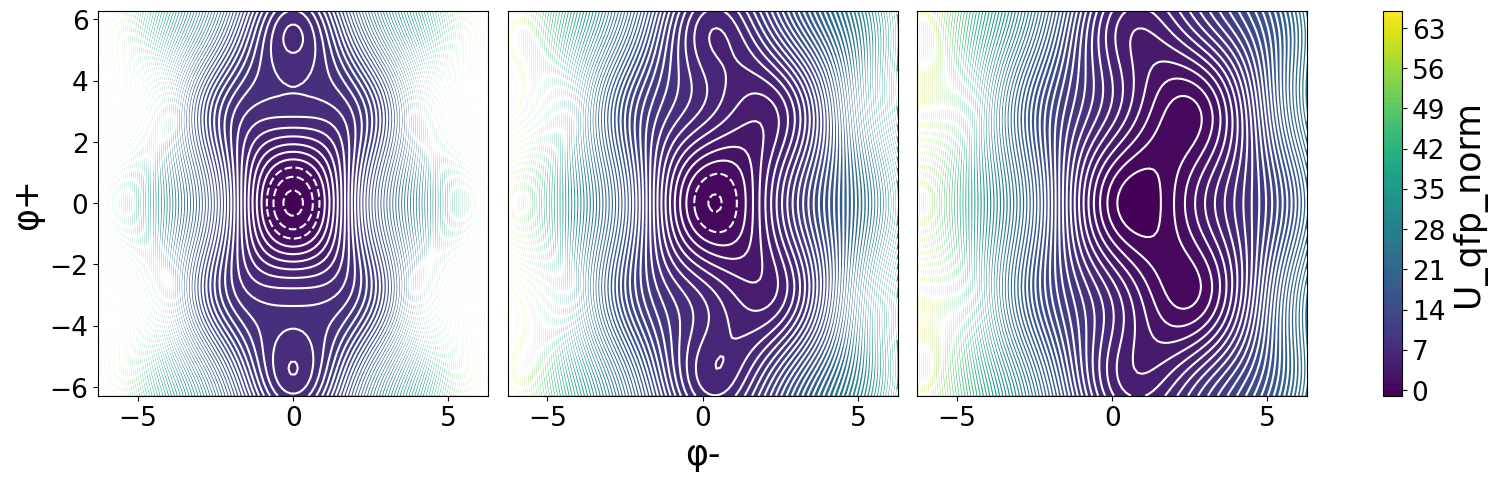

In [109]:
#три графика ровненько вместе для трех разных значений Ix
fig, axes = plt.subplots(1, 3, figsize=(19.5, 5), sharey=True)
for ax in axes:
    ax.tick_params(axis='x', labelsize=19)
    ax.tick_params(axis='y', labelsize=19)

axes[0].contour(P_minus, P_plus, U_qfp_norm_1, levels=80, colors='white', linewidths=1.5)
im1 = axes[0].contourf(P_minus, P_plus, U_qfp_norm_1, levels=80, cmap='viridis')
axes[0].set_ylabel('φ+', fontsize=25)

axes[1].contour(P_minus, P_plus, U_qfp_norm_2, levels=80, colors='white', linewidths=1.5)
im2 = axes[1].contourf(P_minus, P_plus, U_qfp_norm_2, levels=80, cmap='viridis')
axes[1].set_xlabel('φ-', fontsize=25)
axes[1].tick_params(axis='y', left=False, labelleft=False)  # убрать и черточки, и цифры

axes[2].contour(P_minus, P_plus, U_qfp_norm_3, levels=80, colors='white', linewidths=1.5)
im3 = axes[2].contourf(P_minus, P_plus, U_qfp_norm_3, levels=80, cmap='viridis')
axes[2].tick_params(axis='y', left=False, labelleft=False)
plt.subplots_adjust(wspace=0.05)

cbar = fig.colorbar(im3, ax=axes, label='U_qfp_norm')
cbar.ax.tick_params(labelsize=19)
cbar.ax.yaxis.label.set_size(25)

#cbar = fig.colorbar(im3, ax=axes[2], label='U_qfp_norm') 
#cbar.ax.tick_params(labelsize=20)   
#cbar.ax.yaxis.label.set_size(25) 
# Общая подпись для оси Y (слева от всех графиков)
#fig.text(0.02, 0.5, 'φ+', va='center', rotation='vertical', fontsize=20)